# Pattern 2 — Parallelization

## The idea in one line
**Run independent LLM calls at the same time, then combine their results.**

## When to use it
Two situations:

1. **Speed** — sub-tasks don't depend on each other, so why wait? Generate a summary, a tweet, and a LinkedIn post about the same article — all at once.
2. **Confidence** — ask the same question three times with different prompts and vote on the answer (e.g. content-moderation checks).

## When *not* to use it
If the steps *do* depend on each other, use **prompt chaining**. Parallelization is only valid when the calls have no ordering between them.

## The shape of the graph

![Parallelization workflow](../images/parallelization.avif)


```
         ┌─► call_llm_1 ─┐
START ───┼─► call_llm_2 ─┼─► aggregator ─► END
         └─► call_llm_3 ─┘
```

In LangGraph, you simply add multiple edges from `START` (or from any single node) to several next nodes. The runtime executes them **concurrently**. A final **aggregator** node merges their outputs.


In [1]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (joke + story + poem)

One topic in, three creative outputs generated in parallel, merged at the end.


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


def call_llm_1(state: State):
    """Joke branch."""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Story branch."""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Poem branch."""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine joke, story, and poem into a single output."""
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


parallel_builder = StateGraph(State)
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Three parallel edges from START
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")

# All three converge into the aggregator
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

graph = parallel_builder.compile()


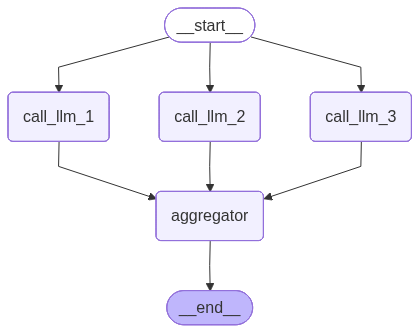

In [3]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
state = graph.invoke({"topic": "Mobile"})
print(state["combined_output"])


Here's a story, joke, and poem about Mobile!

STORY:
[{'type': 'text', 'text': 'The phone didn’t just live in Elias’s pocket; it lived in his palm. It was the first thing he felt in the morning—a cold, glass slab that warmed under his thumb—and the last thing he saw at night, its blue light staining his retinas like a digital sunset.\n\nElias was a "digital nomad." He told people this with a certain pride, usually while sitting in a coffee shop in a city whose name he had to check on his weather app. He was the definition of *mobile*. He had no lease, no heavy furniture, and no desktop computer. His entire existence—his bank accounts, his work as a freelance coder, his memories in the cloud, and his social life—was condensed into six inches of circuitry.\n\nOne Tuesday, Elias found himself in Mobile, Alabama. He hadn’t planned on being there; a cheap bus ticket and a whim had brought him to the humid, moss-draped streets of the Port City.\n\nHe was sitting on a bench in Bienville Squar

## Example 2 — Real use case: multi-channel content generator

You wrote an article. You want three deliverables from it, fast:

- A 2-sentence summary (for a newsletter)
- A 280-character tweet
- A LinkedIn post with emoji bullets

These are independent reformatting tasks, perfect for parallel execution.


In [9]:
class ContentState(TypedDict):
    article: str
    summary: str
    tweet: str
    linkedin: str
    bundle: str


def make_summary(state: ContentState):
    msg = llm.invoke(
        f"Write a 2-sentence newsletter blurb for this article:\n\n{state['article']}"
    )
    return {"summary": msg.content[0]['text']}


def make_tweet(state: ContentState):
    msg = llm.invoke(
        "Write a single tweet (max 280 chars, no hashtags) that captures the key idea of this article. "
        f"Return only the tweet:\n\n{state['article']}"
    )
    return {"tweet": msg.content[0]['text']}


def make_linkedin(state: ContentState):
    msg = llm.invoke(
        "Write a LinkedIn post about this article. Use 3 emoji bullet points and a closing question. "
        f"Article:\n\n{state['article']}"
    )
    return {"linkedin": msg.content[0]['text']}

def bundle(state: ContentState):
    bundled = (
        f"SUMMARY\n-------\n{state['summary']}\n\n"
        f"TWEET\n-----\n{state['tweet']}\n\n"
        f"LINKEDIN\n--------\n{state['linkedin']}"
    )
    return {"bundle": bundled}


content_wf = StateGraph(ContentState)
content_wf.add_node("make_summary", make_summary)
content_wf.add_node("make_tweet", make_tweet)
content_wf.add_node("make_linkedin", make_linkedin)
content_wf.add_node("bundle", bundle)

for branch in ("make_summary", "make_tweet", "make_linkedin"):
    content_wf.add_edge(START, branch)
    content_wf.add_edge(branch, "bundle")

content_wf.add_edge("bundle", END)
graph = content_wf.compile()


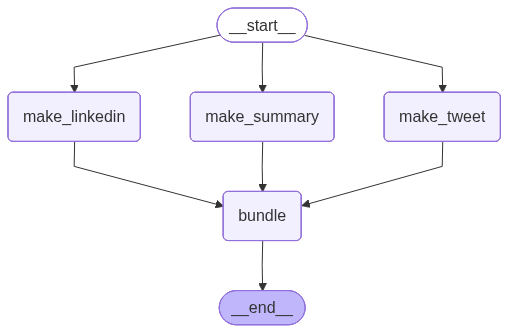

In [6]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [10]:
article = (
    "LangGraph is a library for building stateful, multi-step applications with LLMs. "
    "It represents the application as a graph of nodes (Python functions) and edges, "
    "with a shared state object flowing between them. This makes complex agentic workflows "
    "easier to reason about, debug, and deploy."
)

out = graph.invoke({"article": article})
print(out["bundle"])


SUMMARY
-------
LangGraph is a library designed for building stateful, multi-step LLM applications by representing complex workflows as a structured graph of nodes and edges. This framework simplifies the development of sophisticated AI agents, making them significantly easier to visualize, debug, and deploy.

TWEET
-----
LangGraph transforms complex LLM workflows into stateful graphs. By using nodes for functions and edges to pass shared state, it provides a clear structure for building, debugging, and deploying advanced AI agents. Simple to reason about, powerful to execute.

LINKEDIN
--------
AI Agents just got a major upgrade. 🚀

If you’ve been struggling to manage complex, multi-step LLM workflows, **LangGraph** is the library you need to know about. By representing applications as structured graphs, it brings order to the chaos of agentic development.

Here is why it’s a game-changer for AI developers:

🔹 **Graph-Based Logic:** Map out your application using nodes (Python functio

In [8]:
print(out["bundle"])

SUMMARY
-------
[{'type': 'text', 'text': 'Build more sophisticated AI agents with LangGraph, a library that represents complex LLM workflows as stateful graphs of nodes and edges. This framework simplifies the development process, making it easier to reason about, debug, and deploy high-level agentic applications.', 'extras': {'signature': 'EuIOCt8OAQw51sdCon4WY0ALfaYRkf3FKSCoR2hdIev8VinAHJ1eOSysdcVXxODiC8lcYw5uqGeHIL2YY9TEhM4TCxbipcugRO65aF7sHDcxqReyhAn4+oCv4pHdtqlMFAsjM0mSERkGtv/UHmUuddcmhL9zA0p+iJcS0wheXGzPmIRM3V8RMcdtt55I8zs28yzoWO5YktHBruLdo/27AHUpx6jq0/MkB23eqxv3l4H5QX8DdsDzI/UACCiUb9IV3oXXajsXFapTHcfcTXlcKNVeZhK4a7sG7Xr4sxjJjuYzbIN22L0a/d3x1VBDyAW2CQUeWs9gGJG7iFkJfL3RlnoetffhK/m0fopuTHT9ALtxTnSX50Gj4gXAJemuyNOaMHJgrTyDI7jDzu9cpdTrITc/QlJ+VDnar12XRtflLFwy5R1shI9n6VvvQdgRy3pmqlm9NYWd74SGcZdbrgZgcFaLZ9RBmhd9reemQiIwOwnFowe5fVW2UCvKdzPX+NSGxeSvq/P1VPGtWB2H+ycVPZ4Q+YgARVyar5fpROXsGxiAw3dFaTsNcD3wM1IO0BKpI2d4UQozED37bhEnwAfTH/uFkJ0Qw9hQ0GY0Gru3LW3wUs+bGQh/3cW7wy/y/lw+fdHTorE5qR+9IYhx

## Takeaways

- Multiple edges from the same node = **parallel execution**.
- An **aggregator** node joins the branches back together.
- Cuts wall-clock time compared to running the same calls sequentially.
- Only use when the sub-tasks are genuinely independent.

## Try it yourself

- Given a product name, fan out three branches that generate: (a) an Amazon-style bullet list, (b) a short ad copy, (c) an SEO meta description. Aggregate them into one marketing brief.
